In [1]:
import sys
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from torchvision import transforms

# Add the project root and src directories to the Python path
project_root = os.path.abspath('..')
src_path = os.path.join(project_root, 'src')

# Forcefully insert these exact paths into Python's system path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

    
from model import get_model
from config import IMAGE_SIZE

print("Paths configured successfully!")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_weights_path = r"../model_checkpoints/raddino_best_model.pth"

model = get_model()
model.load_state_dict(torch.load(model_weights_path, map_location=device))
model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

c:\Users\Rald999\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Paths configured successfully!


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1936.77it/s]


In [2]:
def compute_rollout(attentions):
    result = torch.eye(attentions[0].size(-1)).to(attentions[0].device)
    for attention in attentions:
        attention_heads_fused = attention.mean(axis=1)
        attention_heads_fused += torch.eye(attention_heads_fused.size(-1)).to(attention.device)
        attention_heads_fused = attention_heads_fused / attention_heads_fused.sum(dim=-1, keepdim=True)
        result = torch.matmul(attention_heads_fused, result)
    return result

def get_heatmap(model, input_tensor):
    # --- THE FIX: Force the Hugging Face config to output attentions ---
    model.encoder.config.output_attentions = True
    model.encoder.config.return_dict = True
    
    outputs = model.encoder(input_tensor, output_attentions=True, return_dict=True)
    
    # Safety Check
    if outputs.attentions is None or len(outputs.attentions) == 0:
        raise ValueError("Error: The model refused to return attention weights! Ensure attn_implementation='eager' is in model.py.")
    
    cls_token = outputs.pooler_output
    logits = model.classifier(cls_token)
    probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
    
    rollout = compute_rollout(outputs.attentions)
    cls_attention = rollout[0, 0, 1:]
    
    grid_size = int(np.sqrt(cls_attention.size(0)))
    attention_map = cls_attention.reshape(grid_size, grid_size).cpu().numpy()
    attention_map = (attention_map - np.min(attention_map)) / (np.max(attention_map) - np.min(attention_map))
    heatmap = cv2.resize(attention_map, (IMAGE_SIZE, IMAGE_SIZE))
    
    return heatmap, probs

# Standard validation transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Tracking Class 1 (Base Confidence: 0.6868)
Deletion AUC: 0.2020 (Lower is better)
Insertion AUC: 0.5441 (Higher is better)


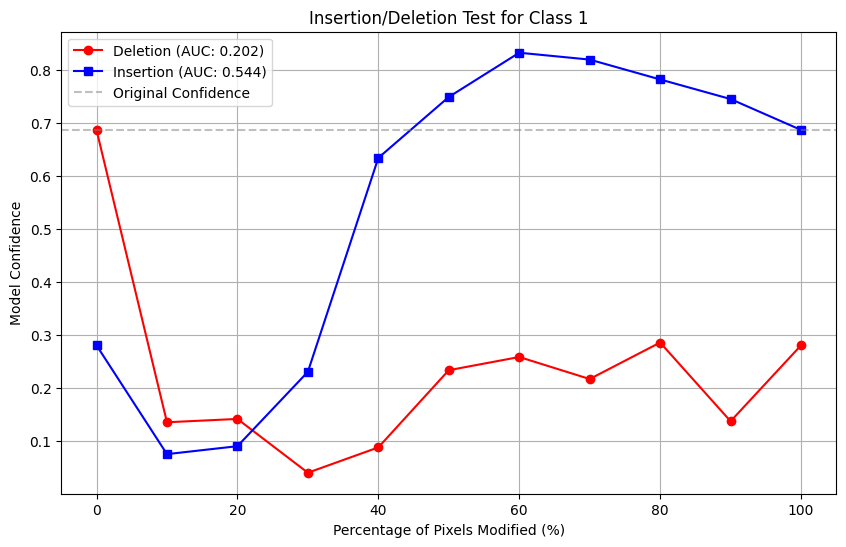

In [3]:
# Updated to your explicit image path
image_path = "../dataset/00000001_000.png"

# Load image and generate baseline predictions
original_image = cv2.imread(image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(original_image, (IMAGE_SIZE, IMAGE_SIZE))
input_tensor = transform(resized_image).unsqueeze(0).to(device)

# Get the initial heatmap and predictions
heatmap, base_probs = get_heatmap(model, input_tensor)

target_class_idx = np.argmax(base_probs)
base_confidence = base_probs[target_class_idx]
print(f"Tracking Class {target_class_idx} (Base Confidence: {base_confidence:.4f})")

# Sort pixels by importance from the heatmap
flat_heatmap = heatmap.flatten()
sorted_indices = np.argsort(flat_heatmap)[::-1]
total_pixels = len(sorted_indices)

# Create a neutral grey baseline image
mean_color = np.array([0.485, 0.456, 0.406]) * 255
neutral_image = np.full_like(resized_image, mean_color, dtype=np.uint8)

deletion_scores = []
insertion_scores = []
steps = 10
fractions = np.linspace(0, 1.0, steps + 1)

# Progressively blackout/reveal pixels and test confidence
with torch.no_grad():
    for frac in fractions:
        num_pixels_to_modify = int(frac * total_pixels)
        pixels_to_modify = sorted_indices[:num_pixels_to_modify]
        
        # --- Deletion ---
        del_img = resized_image.copy().reshape(-1, 3)
        if len(pixels_to_modify) > 0:
            del_img[pixels_to_modify] = neutral_image.reshape(-1, 3)[0]
        del_img = del_img.reshape(IMAGE_SIZE, IMAGE_SIZE, 3)
        del_tensor = transform(del_img).unsqueeze(0).to(device)
        del_prob = torch.sigmoid(model(del_tensor))[0, target_class_idx].item()
        deletion_scores.append(del_prob)
        
        # --- Insertion ---
        ins_img = neutral_image.copy().reshape(-1, 3)
        if len(pixels_to_modify) > 0:
            ins_img[pixels_to_modify] = resized_image.reshape(-1, 3)[pixels_to_modify]
        ins_img = ins_img.reshape(IMAGE_SIZE, IMAGE_SIZE, 3)
        ins_tensor = transform(ins_img).unsqueeze(0).to(device)
        ins_prob = torch.sigmoid(model(ins_tensor))[0, target_class_idx].item()
        insertion_scores.append(ins_prob)

del_auc = auc(fractions, deletion_scores)
ins_auc = auc(fractions, insertion_scores)

print(f"Deletion AUC: {del_auc:.4f} (Lower is better)")
print(f"Insertion AUC: {ins_auc:.4f} (Higher is better)")

# Plot the AUC Graph
plt.figure(figsize=(10, 6))
plt.plot(fractions * 100, deletion_scores, label=f'Deletion (AUC: {del_auc:.3f})', color='red', marker='o')
plt.plot(fractions * 100, insertion_scores, label=f'Insertion (AUC: {ins_auc:.3f})', color='blue', marker='s')
plt.axhline(y=base_confidence, color='gray', linestyle='--', alpha=0.5, label='Original Confidence')
plt.title(f'Insertion/Deletion Test for Class {target_class_idx}')
plt.xlabel('Percentage of Pixels Modified (%)')
plt.ylabel('Model Confidence')
plt.legend()
plt.grid(True)
plt.show()